# Modeling: MultiModal AI — Homework 3
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore Vision-Language Models (VLMs) and gain hands-on experience fine-tuning one.

---

## Environment Setup

Go to the top menu:  
Runtime → Change runtime type → Hardware accelerator → Choose "A100"

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:  
https://colab.research.google.com/signup


# Part 1: Reading & Reflection (20 points)

### Required Reading
[Multimodal Few-Shot Learning with Frozen Language Models](https://arxiv.org/pdf/2106.13884)

[Quality Not Quantity: On the Interaction between Datase Design and Robustness of CLIP
](https://arxiv.org/pdf/2208.05516.pdf)

[Generative AI: Here to stay, but for good?](https://www.sciencedirect.com/science/article/pii/S0160791X2300177X)

---

### Questions
1. What types of multimodal data noise are typically present in multimodal datasets, and how can they negatively impact the performance of a model during training? Can you provide examples of multimodal data points that might be considered noisy? Furthermore, how might we develop estimators capable of distinguishing between noisy and noise-free multimodal data pairs? If you have unlimited fundings to use for data filtering and data cleaning, what would be the ideal way to clean the multimodal dataset?

2. What is the intuition of utilizing frozen large language models as the backbone for multimodal tasks? Which types of encoders would facilitate the integration of diverse information into a format understandable by LLMs? How do these LLMs process and interpret information from different modalities?

3. Ensuring the effectiveness of multimodal foundation models through high-quality instruction tuning is vital. A study detailed at [here](https://arxiv.org/pdf/2402.04333.pdf) introduces a strategy for selecting significant data specifically suited for enhancing instruction tuning for language models. A primary challenge in this approach is determining which data are most crucial for targeted instruction tuning. How can we accurately identify and select the most impactful data for enhancing instruction tuning in multimodal foundation models? Given the complexity of diverse and multimodal information, what strategies can ensure the effectiveness of instruction tuning data for specific tasks?

4. With the advancement of generative AI, distinguishing between AI-generated and human-created content is becoming increasingly challenging. Besides watermarking, which has its limitations, are there other effective methods to differentiate between AI-generated and human-created content across various modalities (text, audio, video, image)? Or is it becoming virtually impossible to make this distinction?

5. For state-of-the-art video generation models like Sora, Yann Lecun mentioned in [here](https://twitter.com/ylecun/status/1758740106955952191) that Sora does not understand the real world and its corresponding physical rules. Do you agree with this view? Can the future development of generative AI systems truly incorporate real-world knowledge, or are they limited in this aspect? Is pursuing generative AI a viable path towards achieving Artificial General Intelligence (AGI)?


# Part 2: Testing and Fine-tuning VLMs (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.  
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.  
- The **secret word** displayed by your verification cell.

---

In [1]:
!pip install transformers accelerate bitsandbytes pillow torch -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 42
cipher_bytes = [99, 10, 102, 101, 124, 111, 10, 103, 103, 107, 99]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = torch.bitwise_xor(cipher, KEY)
    torch.cuda.synchronize()
    secret = bytes(decoded.tolist()).decode("ascii")
    print("SECRET_WORD:", secret)
else:
    print("SECRET_WORD: (not on GPU)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.9 MB/s eta 0:00:00:00:0100:01
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-40GB
SECRET_WORD: I LOVE MMAI


### GPU Verification Screenshot

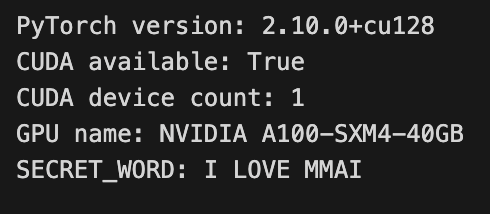


# Problem 2: Prepare Your Dataset (20 points)

## **PLEASE READ THIS ENTIRE SECTION BEFORE PROCEDING**

For Problem 2, you will **use the dataset you have collected from Homework 1 and Homework 2 or a completely new one if you prefer** to fine-tune a Vision-Language Model (VLM).

Even if your original data isn't image-based (e.g. it's audio, time-series, or text), you should find a way to **visualize it** meaningfully. The dataset you prepare will serve as the foundation for model fine-tuning in later steps.

---

### How to Convert Your Project Data Into Images

**If your project is not originally image-based, consider these ideas to generate visual input:**

| Data Type                    | Visual Representation Example                          |
|-----------------------------|---------------------------------------------------------|
| Time-series / sensor data   | Line plots or multi-panel charts (with axis labels)     |
| Audio / Music / Physiology  | Spectrograms or waveform plots                         |
| 3d data (point clouds, CAD) | Rendering/splicing into 2D images

You are encouraged to be **creative and domain-specific** in your visualizations.

**You will need to explore ways to convert your data into images if it does not already consist of this modality. Research on your own and come up with the needed code to do so. If you are still stuck on figuring this out, please reach out to a TA for help!**

### Download Example Training Data

The next block of code will download an example dataset and create a folder named `mmai-data/`.  
Inside this folder, you will find:

```
mmai-data/
├── images/
│   ├── 1.jpg
│   └── 2.jpg
└── data.jsonl
```

The file `data.jsonl` contains your training annotations.  
Each line represents one training example with the following fields:

```json
{
  "image": "images/1.jpg",
  "question": "List objects you see.",
  "answer": "cat, sofa, blanket, remote, cushion"
}
```

---

### Your Task

Now, prepare your own dataset following the same structure as the example.


Example structure:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   ├── image_02.jpg
│   ├── ...
└── data.jsonl
```

As part of this task. You should split the data into a train and test split. **The test split should consist of the images of data that you will not use in training.**


In [2]:
import os, shutil, zipfile
from pathlib import Path

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Pokemon VLM dataset uploaded to Google Drive
URL = "https://drive.google.com/file/d/1MSulIdqBAfbB50IheLLVZ07xUeLwUvGQ/view?usp=drive_link"
# ^^^ Replace YOUR_FILE_ID_HERE with the actual file ID from your Drive URL
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

DATA_DIR = Path("/content/")
DATA_DIR.mkdir(parents=True, exist_ok=True)

!pip -q install gdown
import gdown

print("Downloading Pokemon VLM dataset…")
downloaded_path = gdown.download(URL, output=None, quiet=False, fuzzy=True)
if not downloaded_path or not os.path.exists(downloaded_path):
    raise RuntimeError("Download failed. Check the URL or your Drive permissions.")

src = Path(downloaded_path)
dst = DATA_DIR / src.name
if src.resolve() != dst.resolve():
    shutil.move(str(src), str(dst))

print(f"\nFile saved to: {dst}")

if zipfile.is_zipfile(dst):
    # Extract directly to /content/ — the zip already contains a pokemon-vlm-data/ folder
    print(f"Unzipping into: {DATA_DIR}")
    with zipfile.ZipFile(dst, "r") as zf:
        zf.extractall(DATA_DIR)
    print("Unzip complete.")

# Verify structure
import json
data_root = "/content/pokemon-vlm-data"
train_jsonl = os.path.join(data_root, "data.jsonl")
test_jsonl = os.path.join(data_root, "test_data.jsonl")

with open(train_jsonl) as f:
    train_lines = [json.loads(l) for l in f if l.strip()]
with open(test_jsonl) as f:
    test_lines = [json.loads(l) for l in f if l.strip()]

print(f"\nDataset loaded:")
print(f"  Train: {len(train_lines)} QA pairs")
print(f"  Test:  {len(test_lines)} QA pairs")
print(f"\nSample train entry: {train_lines[0]}")
print(f"Sample test entry:  {test_lines[0]}")

Downloading...
From: https://drive.google.com/uc?id=1MSulIdqBAfbB50IheLLVZ07xUeLwUvGQ
To: /content/pokemon-vlm-data.zip
100%|██████████| 2.82M/2.82M [00:00<00:00, 267MB/s]


File saved to: /content/pokemon-vlm-data.zip
Unzipping into: /content
Unzip complete.

Dataset loaded:
  Train: 360 QA pairs
  Test:  64 QA pairs

Sample train entry: {'image': 'images/train/pokemon_001.jpg', 'question': 'What type is this Pokemon?', 'answer': 'Water'}
Sample test entry:  {'image': 'images/test/pokemon_test_001.jpg', 'question': 'What type is this Pokemon?', 'answer': 'Water'}


## Questions to Answer:

*   Explain some possible issues with converting non-image data into images (even if you did not have to do so, discuss what could be some issues).

*   What are some possible issues with using visual representations of your data. Discuss some drawbacks of doing this (if you did not have to do the conversion as your data was already in the form of images, then discuss the drawbacks of converting those images to another modality like text, audio, etc.).

* Discuss the strategy you decided on how to split your data into train/test splits. Why did you settle on this? Were any other alternative splits considered?



# Problem 3: Baseline Inference (10 points)

# Problem 3.1 Load the Model

Begin by running the following code to **load the base model** into memory. This step is required before training or making predictions.


In [3]:
import io, requests, torch
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1) Load model + processor (processor handles BOTH text + vision)
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
print("Model and tokenizer loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model and tokenizer loaded successfully.


# Problem 3.2: Run the Model on Your 4 Held-Out Images

In this step, you will use the **pre-trained** `Qwen2.5-VL-3B-Instruct` model (no fine-tuning yet) to answer questions about the **held-out images** that were **not used in training**. You will then compare the model’s predictions with the ground-truth labels and reflect on its performance.

---

## Instructions

1. **Select four held-out images**  
   Choose four test images from your dataset that were excluded from training and prompt development.

2. **Ask a consistent question**  
   Use the same question for all images, or a small set of label-aligned questions.

3. **Run the model**  
   Use the provided code cell to run inference with the pre-trained model.  

4. **Record your results**  
   For each image, collect the model’s raw output and compare it to the ground-truth label(s). If there are too many images, then show a few examples.

---

## Reflection (5–8 sentences)

After running the model on your four images, briefly discuss:
- **What worked?**  
  Which prompts or parameter settings produced better results?
- **What failed?**  
  Were there recurring failure modes (e.g., hallucinations, vague answers)?
- **Patterns in mistakes**  
  Did errors correlate with certain categories, lighting conditions, or question phrasing?

---

## Suggested Output Format

| Image ID/URL | Question | Model Output | Ground Truth | Result |
|---------------|-----------|---------------|---------------|---------|
| `img_001.jpg` | “What objects are visible?” | cat, sofa | cat, sofa | Correct |
| `img_002.jpg` | “What objects are visible?” | road, truck, sign | road, car, sign | Incorrect |


--- Active Prompt Config ---
  Prompt   : You are a helpful assistant.
  Question : What type is this Pokemon?
Running baseline inference on 4 held-out images...

Image                               Question                       Model Output              Ground Truth         Result
---------------------------------------------------------------------------------------------------------------------------------------


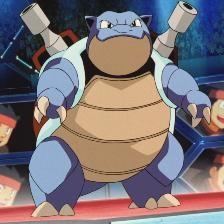

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


images/test/pokemon_test_001.jpg    What type is this Pokemon?     This Pokémon is a Groudon Water                Incorrect



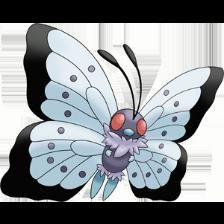

images/test/pokemon_test_005.jpg    What type is this Pokemon?     This is a Butterfree, whi Bug and Flying       Correct



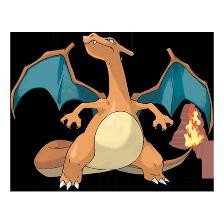

images/test/pokemon_test_009.jpg    What type is this Pokemon?     This is Charizard, a lege Fire and Flying      Correct



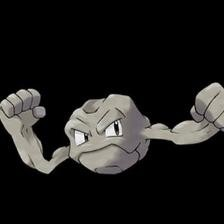

images/test/pokemon_test_013.jpg    What type is this Pokemon?     This is a Rock-type Pokém Rock and Ground      Correct



In [4]:
import json, os, torch, re
from PIL import Image
from IPython.display import display

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
SYSTEM_PROMPT = "You are a helpful assistant."
QUESTION = "What type is this Pokemon?"

# --- Experiment 1: Pokemon eExpert System Prompt ---
# SYSTEM_PROMPT = "You are a Pokemon expert. When shown an image of a Pokemon, identify its type. Answer with only the type name (e.g., Fire, Water, Grass, Electric)."
# QUESTION = "What type is this Pokemon?"

# --- Experiment 2: Few-shot prompt ---
# SYSTEM_PROMPT = "You are a Pokemon type classifier. Examples: Charmander is Fire type. Squirtle is Water type. Bulbasaur is Grass type. Now classify the Pokemon shown."
# QUESTION = "What type is this Pokemon? Answer with only the type."

# --- Experiment 3: Constrained output ---
# SYSTEM_PROMPT = "You are a Pokemon expert."
# QUESTION = "What type is this Pokemon? Choose from: Normal, Fire, Water, Electric, Grass, Ice, Fighting, Poison, Ground, Flying, Psychic, Bug, Rock, Ghost, Dragon, Fairy. Answer with one word only."

# --- Experiment 4: Chain of thought ---
# SYSTEM_PROMPT = "You are a Pokemon expert."
# QUESTION = "Look at this Pokemon carefully. Based on its visual appearance (color, shape, features), what Pokemon type is it? Think step by step, then give your final answer."

MAX_NEW_TOKENS = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

DATA_ROOT = "/content/pokemon-vlm-data"
TEST_JSONL = os.path.join(DATA_ROOT, "test_data.jsonl")

# Load test data and pick 4 diverse images (one per held-out species)
with open(TEST_JSONL) as f:
    test_data = [json.loads(l) for l in f if l.strip()]

# Filter to just "What type is this Pokemon?" questions, pick 4 images of different types (different species)
seen_types = set()
test_samples = []
for ex in test_data:
    if ex["question"] == "What type is this Pokemon?" and ex["answer"] not in seen_types:
        seen_types.add(ex["answer"])
        test_samples.append(ex)
    if len(test_samples) >= 4:
        break

print(f"\n--- Active Prompt Config ---")
print(f"  Prompt   : {SYSTEM_PROMPT}")
print(f"  Question : {QUESTION}")
print(f"Running baseline inference on {len(test_samples)} held-out images...\n")
print(f"{'Image':<35} {'Question':<30} {'Model Output':<25} {'Ground Truth':<20} {'Result'}")
print("-" * 135)

for ex in test_samples:
    img_path = os.path.join(DATA_ROOT, ex["image"])
    img = Image.open(img_path).convert("RGB")

    # Display image
    display(img)

    messages = [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": [
            {"type": "image", "image": img},
            {"type": "text", "text": ex["question"]},
        ]},
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[img], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        gen_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)

    output = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    # Extract just the assistant response
    if "assistant" in output:
        output = output.split("assistant")[-1].strip()

    # Credit if the model gets any one of the correct types (handles dual-type Pokemon)
    types = [t.strip().lower() for t in re.split(r"[/,]|\s+and\s+", ex["answer"])]
    correct = any(t and t in output.lower() for t in types)
    result = "Correct" if correct else "Incorrect"
    print(f"{ex['image']:<35} {ex['question']:<30} {output[:25]:<25} {ex['answer']:<20} {result}")
    print()

# Problem 4: Prompt Engineering (15 points)

In this step, you'll experiment with **prompt design** to explore how different instructions influence model performance.

---

### Instructions

1. Modify the **`SYSTEM_PROMPT`** variable inside the **CHANGE ME** section of the code above.  
2. Re-run the corresponding code cell to observe how the model's responses change.  
3. Test various prompt strategies, such as:
   - Adding **examples** (few-shot prompting)
   - Restricting **answer formats** (e.g., "Answer with one word")
   - Asking for **explanations** or **step-by-step reasoning**
4. Compare your new results with the baseline output.

---

### Reflection

In your write-up, discuss:
- Which types of prompt changes improved performance?  
- Did adding context or structure help the model reason more effectively?  
- Were there any surprising or inconsistent results?


# Problem 5: LoRA Fine-Tuning (20 points)

In this step, you'll fine-tune a **Vision-Language Model (VLM)** using **LoRA (Low-Rank Adaptation)** on your dataset.  
This exercise will help you understand how different hyperparameters influence performance, GPU memory usage, and output quality.

### Instructions

Run the code block below.  
If you followed the **`mmai-data`** example, the script should automatically detect and load your training dataset.

### Adjust and experiment with

- **Number of epochs** (`NUM_EPOCHS`)
- **Learning rate** (`LR`)
- **Batch size per device** (`BSZ_PER_DEV`)
- **Gradient accumulation steps** (`GRAD_ACCUM`)
- **Evaluation split ratio** (`EVAL_SPLIT`)
- **Random seed** (`SEED`)
- **Sequence length** (`MAX_SEQ_LEN`)
- **Image resolution** (`SHORTEST_EDGE`)
- **LoRA rank** (`LORA_R`)
- **LoRA alpha** (`LORA_ALPHA`)
- **LoRA dropout** (`LORA_DROPOUT`)
- **LoRA target modules** (`LORA_TARGET`)

---

```python
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# (Modify the parameters below in the Colab cell)

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

### Q&A

**Q:** What should I do if I encounter an out-of-memory issue?  
**A:** Your image might be too large. Try resizing it by adding the following line back into your code and experiment with different pixel values:

```python
img.thumbnail((128, 128))  # NOTE: If you run into an out-of-memory error, try adding this line back.
```


In [5]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 10
LR: float        = 5e-6
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 2
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512

# Image preprocessing
SHORTEST_EDGE: int = 288
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
DATA_JSONL: str  = "/content/pokemon-vlm-data/data.jsonl"
OUTPUT_DIR: str  = "/content/qwen2_5_vl_lora_pokemon"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/content/cache_images"
IMAGE_TIMEOUT: int = 15

# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 8
LORA_ALPHA: int      = 16
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "List objects you see.",
            "answer": "cat, sofa, blanket, remote, cushion, tail, paw"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "List objects you see.",
            "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
val_idx = set(idx[:n_val])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="epoch",           # evaluate each epoch for early stopping
    save_strategy="epoch",
    load_best_model_at_end=True,     # required for EarlyStoppingCallback
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 3,686,400 || all params: 3,758,309,376 || trainable%: 0.0981


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,5.874186,6.082739
2,3.380736,3.517020
3,2.388472,2.321335
4,1.440740,1.496825
5,1.106866,1.256893
6,1.180046,1.179735
7,1.175413,1.150898
8,1.154050,1.137593
9,1.021396,1.133258
10,1.064168,1.132633


Training complete. LoRA adapters saved to: /content/qwen2_5_vl_lora_pokemon


# **Questions to answer:**

1. Report the settings you used to get the best model.
  
2. Which hyperparameters did you find have the most impact in the model’s performance?

3. Why do you think that is?



# Problem 6: Post-Training Evaluation (30 points)

# Problem 6.1 Load the Trained LoRA Adapter

Once your fine-tuning is complete, load the trained **LoRA adapters** back onto the original model to perform inference, that is, to generate predictions or analyze new images.

Simply run the code in the next code block.  
It will automatically attach your fine-tuned LoRA weights and prepare the model for evaluation.


In [6]:

# --------------------
# Inference with adapters
# --------------------
from peft import PeftModel
base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    # device_map="cuda:0",
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(base, OUTPUT_DIR)
ft_model.eval()
print("LoRA adapters loaded. Ready for inference.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

LoRA adapters loaded. Ready for inference.


# Problem 6.2 Re-Test on Held-Out Images

Re-test the same **held-out images** used in your baseline evaluation.

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.


Running FINE-TUNED model on 4 held-out images...

Image                               Question                       FT Output                 Ground Truth         Result
---------------------------------------------------------------------------------------------------------------------------------------


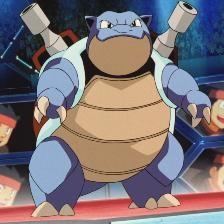

images/test/pokemon_test_001.jpg    What type is this Pokemon?     Fairy                     Water                Incorrect



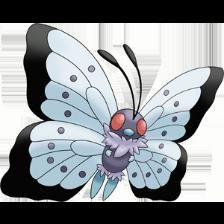

images/test/pokemon_test_005.jpg    What type is this Pokemon?     Fighting                  Bug and Flying       Incorrect



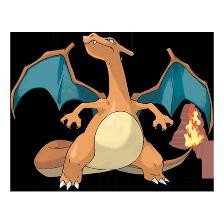

images/test/pokemon_test_009.jpg    What type is this Pokemon?     Psychic                   Fire and Flying      Incorrect



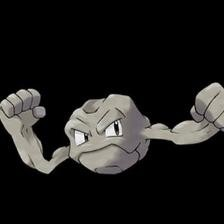

images/test/pokemon_test_013.jpg    What type is this Pokemon?     Fighting                  Rock and Ground      Incorrect



In [7]:
import json, os, torch, re
from PIL import Image
from IPython.display import display

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
TEST_QUESTION = "What type is this Pokemon?"
MAX_NEW_TOKENS = 64
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

DATA_ROOT = "/content/pokemon-vlm-data"
TEST_JSONL = os.path.join(DATA_ROOT, "test_data.jsonl")

with open(TEST_JSONL) as f:
    test_data = [json.loads(l) for l in f if l.strip()]

# Filter to type questions, pick 4 images of different types (different species)
seen_types = set()
test_samples = []
for ex in test_data:
    if ex["question"] == "What type is this Pokemon?" and ex["answer"] not in seen_types:
        seen_types.add(ex["answer"])
        test_samples.append(ex)
    if len(test_samples) >= 4:
        break

print(f"Running FINE-TUNED model on {len(test_samples)} held-out images...\n")
print(f"{'Image':<35} {'Question':<30} {'FT Output':<25} {'Ground Truth':<20} {'Result'}")
print("-" * 135)

for ex in test_samples:
    img_path = os.path.join(DATA_ROOT, ex["image"])
    img = Image.open(img_path).convert("RGB")

    display(img)

    messages = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text", "text": ex["question"]}
    ]}]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[img], return_tensors="pt").to(ft_model.device)

    with torch.no_grad():
        out_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)

    output = processor.batch_decode(out_ids, skip_special_tokens=True)[0]
    if "assistant" in output:
        output = output.split("assistant")[-1].strip()

    # Credit if the model gets any one of the correct types (handles dual-type Pokemon)
    types = [t.strip().lower() for t in re.split(r"[/,]|\s+and\s+", ex["answer"])]
    correct = any(t and t in output.lower() for t in types)
    result = "Correct" if correct else "Incorrect"
    print(f"{ex['image']:<35} {ex['question']:<30} {output[:25]:<25} {ex['answer']:<20} {result}")
    print()

In [8]:
import json, os, torch, re
from PIL import Image

DATA_ROOT = "/content/pokemon-vlm-data"
TEST_JSONL = os.path.join(DATA_ROOT, "test_data.jsonl")

with open(TEST_JSONL) as f:
    test_data = [json.loads(l) for l in f if l.strip()]

# Only evaluate "What type is this Pokemon?" questions
type_questions = [ex for ex in test_data if ex["question"] == "What type is this Pokemon?"]

correct = 0
total = len(type_questions)

print(f"Evaluating fine-tuned model on all {total} type-identification test questions...\n")

for ex in type_questions:
    img_path = os.path.join(DATA_ROOT, ex["image"])
    img = Image.open(img_path).convert("RGB")

    messages = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text", "text": ex["question"]}
    ]}]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[img], return_tensors="pt").to(ft_model.device)

    with torch.no_grad():
        out_ids = ft_model.generate(**inputs, max_new_tokens=64, do_sample=False)

    output = processor.batch_decode(out_ids, skip_special_tokens=True)[0]
    if "assistant" in output:
        output = output.split("assistant")[-1].strip()

    types = [t.strip().lower() for t in re.split(r"[/,]|\s+and\s+", ex["answer"])]
    if any(t and t in output.lower() for t in types):
        correct += 1
    else:
        print(f"  MISS: {ex['image']} — predicted '{output.strip()}', truth '{ex['answer']}'")

print(f"\nAccuracy: {correct}/{total} = {correct/total:.1%}")

Evaluating fine-tuned model on all 32 type-identification test questions...

  MISS: images/test/pokemon_test_001.jpg — predicted 'Fairy', truth 'Water'
  MISS: images/test/pokemon_test_002.jpg — predicted 'Fairy', truth 'Water'
  MISS: images/test/pokemon_test_004.jpg — predicted 'Fighting', truth 'Water'
  MISS: images/test/pokemon_test_005.jpg — predicted 'Fighting', truth 'Bug and Flying'
  MISS: images/test/pokemon_test_006.jpg — predicted 'Water', truth 'Bug and Flying'
  MISS: images/test/pokemon_test_007.jpg — predicted 'Grass/Poison', truth 'Bug and Flying'
  MISS: images/test/pokemon_test_008.jpg — predicted 'Grass/Poison', truth 'Bug and Flying'
  MISS: images/test/pokemon_test_009.jpg — predicted 'Psychic', truth 'Fire and Flying'
  MISS: images/test/pokemon_test_010.jpg — predicted 'Fighting', truth 'Fire and Flying'
  MISS: images/test/pokemon_test_011.jpg — predicted 'Water', truth 'Fire and Flying'
  MISS: images/test/pokemon_test_012.jpg — predicted 'Water', truth 'Fir

# Problem 7: Final Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. What concept did you find the most interesting?
2. Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?